<a href="https://colab.research.google.com/github/yshzjq/Step-2.Statistical_Thinking-Machine-Learning/blob/main/Step%202.%20%ED%86%B5%EA%B3%84%EC%A0%81%20%EC%82%AC%EA%B3%A0%EC%99%80%20%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%20%EC%9E%85%EB%AC%B8/1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 데이터 처리용
import pandas as pd
import numpy as np

# 시각화용
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 계산용
from scipy import stats

In [3]:
# 데이터 URL
url ="/content/Shopping_Mall_Customer_Segmentation_Data_.csv"

# CSV 파일 읽기
df = pd.read_csv(url)

df.head()


,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [5]:
# 전체 고객의 연소득 평균 (모집단 평균 역할)
population_mean = df['Annual Income'].mean()

population_mean


np.float64(109742.88056237152)

In [6]:
# 랜덤 시드 고정
np.random.seed(42)

# 표본 크기 설정
sample_size =30

# 랜덤 표본 추출
sample = df['Annual Income'].sample(sample_size)

sample.head()

,Annual Income
5404,167902
3613,102743
12127,116714
9941,98545
5221,119152


In [7]:
# 표본 평균
sample_mean = sample.mean()

sample_mean


np.float64(112848.6)

In [8]:
# 표본 표준편차
sample_std = sample.std(ddof=1) #ddof는 표본 분산(표준편차) 계산 할 때 보정해주는 역할

# 표본 크기
n =len(sample)

# 표준오차 계산
standard_error = sample_std / np.sqrt(n)

# 95% 신뢰수준의 t 값
t_value = stats.t.ppf(0.975, df=n-1) #양쪽 꼬리 2.5%씩 제외 → 95% / 자유도 df = n - 1

# 신뢰구간 계산
ci_lower = sample_mean - t_value * standard_error
ci_upper = sample_mean + t_value * standard_error

(ci_lower, ci_upper)

(np.float64(93433.13467336232), np.float64(132264.0653266377))

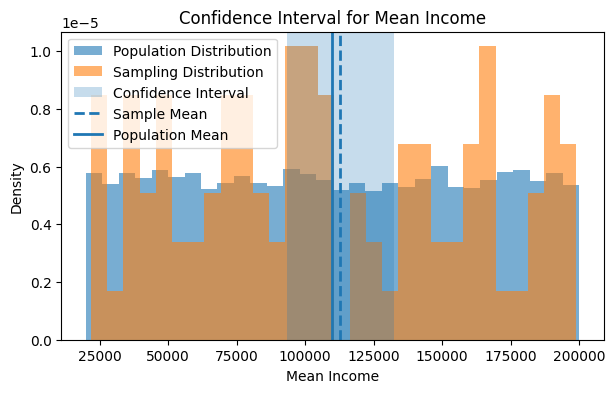

In [11]:
plt.figure(figsize=(7,4))

# 모집단 분포 히스토그램
plt.hist(df['Annual Income'], bins=30, density=True, alpha=0.6, label='Population Distribution')
# density 확률밀도 형태, alpha 투명

# 표본 분포 히스토그램
plt.hist(df['Annual Income'].sample(size), bins=30, density=True, alpha=0.6, label='Sampling Distribution')

# 신뢰구간 표시
plt.axvspan(ci_lower, ci_upper, alpha=0.25, label='Confidence Interval')
# 신뢰구간을 음영 영역으로 표시

# 표본 평균
plt.axvline(sample_mean, linestyle='--', linewidth=2, label='Sample Mean')

# 모집단 평균
plt.axvline(population_mean, linestyle='-', linewidth=2, label='Population Mean')

plt.title('Confidence Interval for Mean Income')
plt.xlabel('Mean Income')
plt.ylabel('Density')
plt.legend()
plt.show()

In [10]:
sample_sizes = [10,20,50,100]
errors = []

for size in sample_sizes:
    sample = df['Annual Income'].sample(size)
    error =abs(sample.mean() - population_mean)
    errors.append(error)

# 결과 테이블 생성
error_df = pd.DataFrame({
'sample_size': sample_sizes,
'mean_error': errors
})

error_df

,sample_size,mean_error
0,10,12154.380562
1,20,1999.869438
2,50,12243.199438
3,100,11610.679438
